In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.width",None)

In [2]:
def find_true_probabilities_equal(odds):
    probabilities = [1/o for o in odds]
    total_probability = sum(probabilities)
    overround = total_probability - 1
    adjustment_factor = overround / len(odds)
    adjusted_probabilities = [(1/o) - adjustment_factor for o in odds]
    return np.array(adjusted_probabilities)


In [3]:
season_list = ['1617', '1718', '1819', '1920', '2021', '2122', '2223', '2324', '2425']

league_list = ['E0', 'E1', 'E2', 'E3', 'SC0', 'SC1', 'SC2', 'D1', 'D2', 'I1', 'I2', 'SP1', 'SP2', 'F1', 'F2', 'N1', 'B1', 'P1', 'T1', 'G1']  

df_list = []
for league in league_list:
    for season in season_list:
        data_url = f'https://www.football-data.co.uk/mmz4281/{season}/{league}.csv'
        try:
            df = pd.read_csv(data_url)
        except:
            df = pd.read_csv(data_url, encoding='latin')
        df_list.append(df)

main_df = pd.concat(df_list)

main_df['Date'] = pd.to_datetime(main_df['Date'], format='mixed')

main_df = main_df.sort_values(by='Date')

bookmakers = ['B365', 'BW', 'IW', 'PS', 'WH', 'VC']

home_cols = []
draw_cols = []
away_cols = []

for book in bookmakers:
    home_col = book + 'H'
    home_cols.append(home_col)
    draw_col = book + 'D'
    draw_cols.append(draw_col)
    away_col = book + 'A'
    away_cols.append(away_col)

main_df['home_max_odds'] = main_df[home_cols].max(axis=1)
main_df['draw_max_odds'] = main_df[draw_cols].max(axis=1)
main_df['away_max_odds'] = main_df[away_cols].max(axis=1)

main_df.reset_index(inplace=True)

col_list = ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'PSH', 'PSD', 'PSA', 'home_max_odds', 'draw_max_odds', 'away_max_odds']

main_df = main_df[col_list]


C:\Users\mikko\AppData\Local\Temp\ipykernel_5392\2168323404.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  main_df['home_max_odds'] = main_df[home_cols].max(axis=1)
C:\Users\mikko\AppData\Local\Temp\ipykernel_5392\2168323404.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  main_df['draw_max_odds'] = main_df[draw_cols].max(axis=1)
C:\Users\mikko\AppData\Local\Temp\ipykernel_5392\2168323404.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

In [4]:
main_df = main_df[~main_df['PSH'].isna()]

main_df.reset_index(inplace=True)

In [5]:
main_df[['pinnacle_true_home_prob', 'pinnacle_true_draw_prob', 'pinnacle_true_away_prob']] = main_df.apply(
    lambda row: find_true_probabilities_equal([row['PSH'], row['PSD'], row['PSA']]),
    axis=1,
    result_type='expand'
)

main_df['totes'] = main_df['pinnacle_true_home_prob'] + main_df['pinnacle_true_draw_prob'] + main_df['pinnacle_true_away_prob']

tolerance = 1e-7
mask = np.abs(main_df['totes'] -1 <= tolerance)

assert len(main_df[~mask]) == 0

len(main_df[~mask])

0

In [6]:
def calculate_ev_from_odds(bookmaker_odds, our_probability):
    payout = bookmaker_odds
    ev = (our_probability * payout) -1
    return ev

In [7]:
assert calculate_ev_from_odds(2.0, 0.5) == 0

In [8]:
calculate_ev_from_odds(3.0, 0.5)

0.5

In [9]:
def calculate_kelly_stake(bankroll, ev, odds, kelly_fraction=0.25):
    if odds <= 1 or kelly_fraction <= 0:
        return 0.0
    
    stake_fraction = ev / (odds - 1)

    if stake_fraction <= 0:
        return 0.0
    
    stake_fraction *= kelly_fraction

    return stake_fraction * bankroll

In [10]:
main_df['home_ev'] = main_df.apply(
    lambda row: calculate_ev_from_odds(
        row['home_max_odds'],
        row['pinnacle_true_home_prob']
    ),
    axis=1
)

In [11]:
main_df['winner_HDA'] = 'D'
main_df.loc[main_df['FTHG'] > main_df['FTAG'], 'winner_HDA'] = 'H'
main_df.loc[main_df['FTHG'] < main_df['FTAG'], 'winner_HDA'] = 'A'

main_df['winner_odds'] = main_df['PSD']  # Default to draw odds
main_df.loc[main_df['winner_HDA'] == 'H', 'winner_odds'] = main_df['PSH']
main_df.loc[main_df['winner_HDA'] == 'A', 'winner_odds'] = main_df['PSA']


In [12]:
bankroll_low_odds = 0

for i in range(len(main_df)):
    bet_size = 1
    outcome = main_df.loc[i, 'winner_HDA']

    if main_df.loc[i, 'PSH'] < 1.5:
        bankroll_low_odds -= bet_size * main_df.loc[i, 'pinnacle_true_home_prob']  # Bet on H
        if outcome == 'H':
            bankroll_low_odds += bet_size * main_df.loc[i, 'PSH'] * main_df.loc[i, 'pinnacle_true_home_prob']
        main_df.loc[i, 'bet_on'] = 'H'

    elif main_df.loc[i, 'PSD'] < 1.5:
        bankroll_low_odds -= bet_size * main_df.loc[i, 'pinnacle_true_draw_prob']  # Bet on D
        if outcome == 'D':
            bankroll_low_odds += bet_size * main_df.loc[i, 'PSD']* main_df.loc[i, 'pinnacle_true_draw_prob']
        main_df.loc[i, 'bet_on'] = 'D'

    elif main_df.loc[i, 'PSA'] < 1.5:
        bankroll_low_odds -= bet_size * main_df.loc[i, 'pinnacle_true_away_prob']  # Bet on A
        if outcome == 'A':
            bankroll_low_odds += bet_size * main_df.loc[i, 'PSA'] * main_df.loc[i, 'pinnacle_true_away_prob']
        main_df.loc[i, 'bet_on'] = 'A'

    else:
        main_df.loc[i, 'bet_on'] = None  # No bet placed

    main_df.loc[i, 'bankroll_low_odds'] = bankroll_low_odds

In [13]:
bankroll_middle_odds = 0

for i in range(len(main_df)):
    bet_size = 1
    outcome = main_df.loc[i, 'winner_HDA']

    if 1.5 <= main_df.loc[i, 'PSH'] <= 2.5:
        bankroll_middle_odds -= bet_size * main_df.loc[i, 'pinnacle_true_home_prob']  # Bet on H
        if outcome == 'H':
            bankroll_middle_odds += bet_size * main_df.loc[i, 'PSH']* main_df.loc[i, 'pinnacle_true_home_prob']
        main_df.loc[i, 'bet_on_middle'] = 'H'

    elif 1.5 <= main_df.loc[i, 'PSD'] <= 2.5:
        bankroll_middle_odds -= bet_size * main_df.loc[i, 'pinnacle_true_draw_prob']  # Bet on D
        if outcome == 'D':
            bankroll_middle_odds += bet_size * main_df.loc[i, 'PSD']* main_df.loc[i, 'pinnacle_true_draw_prob']
        main_df.loc[i, 'bet_on_middle'] = 'D'

    elif 1.5 <= main_df.loc[i, 'PSA'] <= 2.5:
        bankroll_middle_odds -= bet_size * main_df.loc[i, 'pinnacle_true_away_prob'] # Bet on A
        if outcome == 'A':
            bankroll_middle_odds += bet_size * main_df.loc[i, 'PSA'] * main_df.loc[i, 'pinnacle_true_away_prob']
        main_df.loc[i, 'bet_on_middle'] = 'A'

    else:
        main_df.loc[i, 'bet_on_middle'] = None  # No bet placed

    main_df.loc[i, 'bankroll_middle_odds'] = bankroll_middle_odds

In [14]:
bankroll_high_odds = 0

for i in range(len(main_df)):
    bet_size = 1
    outcome = main_df.loc[i, 'winner_HDA']

    if main_df.loc[i, 'PSH'] > 2.5:
        bankroll_high_odds -= bet_size * main_df.loc[i, 'pinnacle_true_home_prob']  # Bet on H
        if outcome == 'H':
            bankroll_high_odds += bet_size * main_df.loc[i, 'PSH'] * main_df.loc[i, 'pinnacle_true_home_prob']
        main_df.loc[i, 'bet_on_high'] = 'H'

    elif main_df.loc[i, 'PSD'] > 2.5:
        bankroll_high_odds -= bet_size * main_df.loc[i, 'pinnacle_true_draw_prob'] # Bet on D
        if outcome == 'D':
            bankroll_high_odds += bet_size * main_df.loc[i, 'PSD'] * main_df.loc[i, 'pinnacle_true_draw_prob']
        main_df.loc[i, 'bet_on_high'] = 'D'

    elif main_df.loc[i, 'PSA'] > 2.5:
        bankroll_high_odds -= bet_size * main_df.loc[i, 'pinnacle_true_away_prob'] # Bet on A
        if outcome == 'A':
            bankroll_high_odds += bet_size * main_df.loc[i, 'PSA'] * main_df.loc[i, 'pinnacle_true_away_prob']
        main_df.loc[i, 'bet_on_high'] = 'A'

    else:
        main_df.loc[i, 'bet_on_high'] = None  # No bet placed

    main_df.loc[i, 'bankroll_high_odds'] = bankroll_high_odds


In [15]:
main_df

,index,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,PSH,PSD,PSA,home_max_odds,draw_max_odds,away_max_odds,pinnacle_true_home_prob,pinnacle_true_draw_prob,pinnacle_true_away_prob,totes,home_ev,winner_HDA,winner_odds,bet_on,bankroll_low_odds,bet_on_middle,bankroll_middle_odds,bet_on_high,bankroll_high_odds
0,0,F2,2016-01-08,Amiens,Reims,1.0,1.0,2.91,2.99,2.88,2.91,3.10,2.88,0.335205,0.326010,0.338785,1.0,-0.024554,D,2.99,None,0.00000,None,0.000000,H,-0.335205
1,1,E3,2016-01-10,Cambridge,Accrington,2.0,1.0,2.77,3.27,2.80,2.77,3.40,2.80,0.353023,0.297822,0.349155,1.0,-0.022127,H,2.77,None,0.00000,None,0.000000,H,0.289645
2,2,E3,2016-01-10,Barnet,Leyton Orient,0.0,0.0,2.66,3.50,2.75,2.66,3.60,2.80,0.367510,0.277284,0.355206,1.0,-0.022424,D,3.50,None,0.00000,None,0.000000,H,-0.077864
3,3,F2,2016-01-10,Strasbourg,Valenciennes,2.0,4.0,1.77,3.20,6.30,1.77,3.40,6.30,0.552904,0.300433,0.146663,1.0,-0.021359,A,6.30,None,0.00000,H,-0.552904,D,-0.378297
4,4,I1,2016-01-10,Udinese,Lazio,0.0,3.0,3.12,3.40,2.47,3.13,3.40,2.50,0.314017,0.287621,0.398362,1.0,-0.017128,A,2.47,None,0.00000,A,0.032688,H,-0.692314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62001,62548,E3,2025-12-04,Harrogate,Grimsby,2.0,2.0,3.77,3.35,2.00,3.77,3.40,2.00,0.243999,0.277254,0.478747,1.0,-0.080124,D,3.35,None,-16.64448,A,-406.579835,H,-604.063307
62002,62549,SP2,2025-12-05,Granada,Eibar,0.0,2.0,1.79,3.44,4.89,1.80,3.44,4.89,0.540707,0.272746,0.186547,1.0,-0.026727,A,4.89,None,-16.64448,H,-407.120542,D,-604.336052
62003,62550,I1,2025-12-05,Venezia,Fiorentina,2.0,1.0,3.11,3.28,2.46,3.11,3.28,2.46,0.310568,0.293903,0.395529,1.0,-0.034133,H,3.11,None,-16.64448,A,-407.516071,H,-603.680753
62004,62551,I1,2025-12-05,Atalanta,Roma,2.0,1.0,2.01,3.56,3.91,2.01,3.60,3.91,0.486124,0.269510,0.244366,1.0,-0.022891,H,2.01,None,-16.64448,H,-407.025086,D,-603.950264


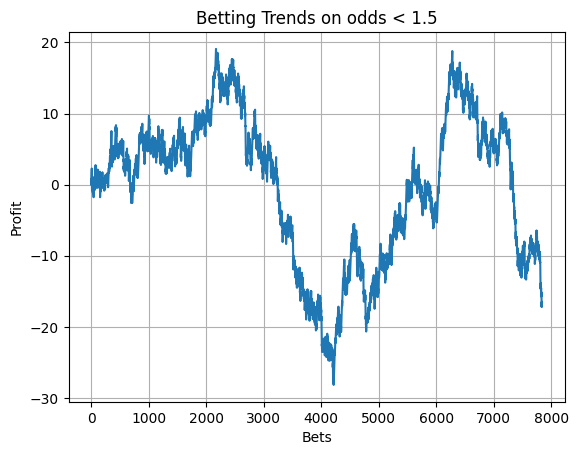

In [16]:
# Filter rows where a low odds bet was placed (i.e., bet_on is not None)
filtered_df = main_df[main_df['bet_on'].notna()]

# Plot only those rows
filtered_df[['bankroll_low_odds']].reset_index(drop=True).plot(legend=False)

plt.title('Betting Trends on odds < 1.5')
plt.xlabel('Bets')
plt.ylabel('Profit')
plt.grid(True)
plt.show()


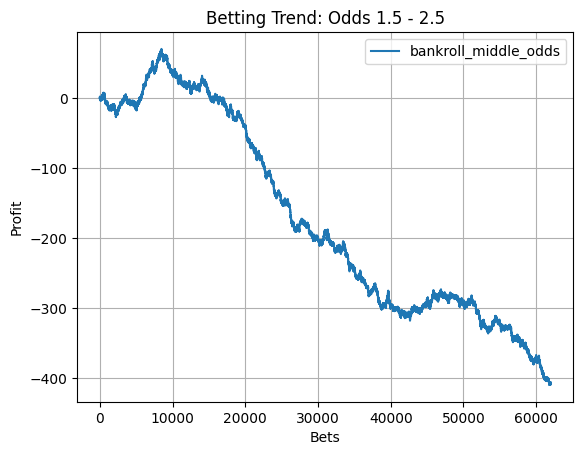

In [17]:
# Filter rows where a middle-odds bet was placed
#filtered_middle = main_df[main_df['bet_on_middle'].notna()]

# Plot bankroll progression
#filtered_middle[['bankroll_middle_odds']].reset_index(drop=True).plot(legend=False)

main_df[['bankroll_middle_odds']].plot()
plt.title('Betting Trend: Odds 1.5 - 2.5')
plt.xlabel('Bets')
plt.ylabel('Profit')
plt.grid(True)
plt.show()


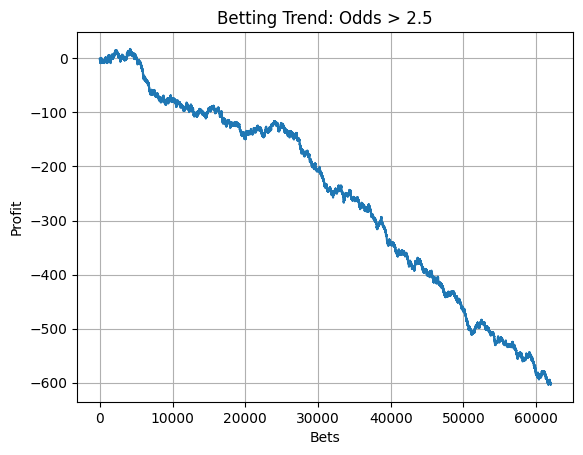

In [18]:
import matplotlib.pyplot as plt

# Filter rows where a high-odds bet was placed
filtered_high = main_df[main_df['bet_on_high'].notna()]

# Plot bankroll progression
filtered_high[['bankroll_high_odds']].reset_index(drop=True).plot(legend=False)

plt.title('Betting Trend: Odds > 2.5')
plt.xlabel('Bets')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

In [19]:
#main_df.to_csv('C:/Users/mikko/OneDrive/Desktop/filename.csv', index=True)
